# Encoding analysis: wilbur20210512

**Contents**

1. [Setup](#Setup)
2. [Single-variable models](#Single-variable-models)
   - Null - History - Trial type - Choice - Speed - Position - Trial progress
3. [Combined models](#Combined-models)
   - Full (using linear position) - Temporal (using trial progress)
4. [Model comparison](#Model-comparison)
   - Single-variable AIC/LRT - Drop-one & LRT


In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir("..")
    
%matplotlib qt
%config InlineBackend.figure_format = 'retina'
sns.set_context("talk")

%reload_ext autoreload
%autoreload 2
pd.options.display.max_columns = 50
pd.set_option('display.float_format', lambda x: '%.9f' % x)

In [2]:
import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy import stats         
from scipy.stats import chi2 
from functools import partial
from notebooks.encoding_utils import *
from notebooks.spike_visualisation import *

In [3]:
import spyglass.linearization.v1 as sgpl

graph = sgpl.TrackGraph() & {"track_graph_name":"Wtrack_center0_wilbur20210512"}
# fig, ax = plt.subplots()
# graph.plot_track_graph(draw_edge_labels=True, ax = ax)

[2026-04-22 15:44:40,500][INFO]: DataJoint 0.14.9 connected to anirudh@172.16.102.154:3306


## Setup

### Load data

In [4]:
base_dir = CONFIG["base_dir"]
BIN_SIZE = CONFIG["bin_size"]

data = load_and_prepare_data()
cov_df_correct = data["cov_df_correct"] #covariate dataframe, data from all correct trials
spike_counts_correct = data["spike_counts_correct"]
cov_df_common        = data["cov_df_common"] #covariate dataframe, conv_df_correct + runs_only mask
cov_df_out_common    = data["cov_df_out_common"] # only outbound trials, for choice analysis
spike_counts_common  = data["spike_counts_common"]
spike_counts_out_common = data["spike_counts_out_common"]
unit_ids             = data["unit_ids"]
bin_centers          = data["bin_centers"]
sp                   = data["scaling_params"]
pos_min_val, pos_max_val   = sp["pos_min"], sp["pos_max"]
speed_min_val, speed_max_val = sp["speed_min"], sp["speed_max"]

# trialized position : used by W-track visualization
trialized_position = pd.read_csv(CONFIG["trialized_position"], index_col="time")

print(f"cov_df_common: {len(cov_df_common):,} bins")
print(f"cov_df_out_common: {len(cov_df_out_common):,} bins (outbound)")

# model registry 
registry = build_model_registry()

cov_df_common: 435,816 bins
cov_df_out_common: 191,405 bins (outbound)


### Models:

#### Single-variable models:
1. Null model (constant rate)
2. Null model (outbound only, for comparison with other outbound-only models)
3. spike_count ~ history terms 
2. spike_count ~ trial_type (categorical)
3. spike_count ~ left/right choice (categorical)
4. spike_count ~ bs(speed, df = 4) (spline)
5. spike_count ~ bs(linear_position, df = 8) (spline)
6. spike_count ~ cr(progress, df= 6) (spline)

#### Mutli-variable models:
1. spike_count ~ trial_type + bs(speed) + bs(linear_position) 
2. spike_count ~ trial_type + bs(speed) + cr(trial_progress)

In [5]:
UNIT_LIST = [12, 47, 103, 211, 58] #for unit grid plots

## Data visualisation

In [25]:
plot_raster(spike_counts_correct, cov_df_correct, epoch = 2, units = UNIT_LIST, plot_position=True); #masked to include outboud/inbound trials, no zone or speed masking

In [26]:
plot_isi_grid(spike_counts_common, units = [115, 45, 118, 119, 22, 37], n_hist_bins=25, max_isi_ms=50);

In [27]:
plot_acg_grid(spike_counts_common, units=[115, 45, 118, 119, 22, 37], max_lag_ms=50, plot_bin_ms=2, epoch=2, cov_df=cov_df_common);

## Single-variable models

### Single-variable model (configurable)

Set `MODEL_KEY` below and re-run the section.
Available keys: `"null"`, `"null_outbound"`, `"trial_type"`, `"choice"`,
`"speed_spline"`, `"pos_spline"`, `"branch_pos_spline"`, `"trial_progress_spline"`

In [33]:
MODEL_KEY = "null"
unit_idx  = 13

# derived
_spec    = registry[MODEL_KEY]
_formula = _spec["formula"]
_datasets = {
    "common":   (cov_df_common, spike_counts_common),
    "outbound": (cov_df_out_common, spike_counts_out_common),
}
_cov_df, _spike_counts = _datasets[_spec["dataset"]]

# extra plot config : only models listed here get an additional plot
EXTRA_PLOT_CONFIG = {
    "trial_type":            {"type": "categorical", "cat_col": "trial_type"},
    "choice":                {"type": "categorical", "cat_col": "choice"},
    "speed_spline":          {"type": "tuning", "scaled_col": "speed_scaled",
                              "actual_col": "speed",
                              "min_val": speed_min_val, "max_val": speed_max_val,
                              "xlabel": "Speed (cm/s)"},
    "pos_spline":            {"type": "tuning", "scaled_col": "pos_scaled",
                              "actual_col": "linear_position",
                              "min_val": pos_min_val, "max_val": pos_max_val,
                              "xlabel": "Position (cm)"},
    "branch_pos_spline":     {"type": "linearized_branch",
                              "actual_col": "linear_position",
                              "xlabel": "Position (cm)"},
    "trial_progress_spline": {"type": "tuning", "scaled_col": "trial_progress",
                              "actual_col": "trial_progress",
                              "xlabel": "Trial progress"},
}

print(f"Model: {MODEL_KEY}  |  Formula: {_formula}  |  Dataset: {_spec['dataset']}  |  Unit: {unit_idx}")

Model: null  |  Formula: spike_count ~ 1  |  Dataset: common  |  Unit: 13


In [34]:
results_single = fit_single_unit(_formula, _cov_df, _spike_counts, unit_idx)
print(results_single.summary())
print("--------------------------------")

_extra = EXTRA_PLOT_CONFIG.get(MODEL_KEY)
if _extra is None:
    # null model: intercept = mean rate
    mean_count = np.exp(results_single.params["Intercept"])
    print(f"Mean firing rate: {mean_count / BIN_SIZE:.2f} Hz")
elif _extra["type"] == "categorical":
    # categorical: rate per category
    cats = sorted(_cov_df[_extra["cat_col"]].dropna().unique())
    syn = pd.DataFrame({_extra["cat_col"]: cats})
    pred_hz = results_single.predict(syn).values / BIN_SIZE
    print("Predicted rate by category:")
    for cat, hz in zip(cats, pred_hz):
        print(f"  {cat}: {hz:.2f} Hz")
elif _extra["type"] == "tuning":
    # spline: rate range
    syn = pd.DataFrame({_extra["scaled_col"]: np.linspace(0, 1, 200)})
    pred_hz = results_single.predict(syn).values / BIN_SIZE
    print(f"Predicted rate range: {pred_hz.min():.2f} \u2013 {pred_hz.max():.2f}/ Hz  (fold change: {pred_hz.max()/pred_hz.min():.1f}\u00d7)")

                 Generalized Linear Model Regression Results                  
Dep. Variable:            spike_count   No. Observations:               435816
Model:                            GLM   Df Residuals:                   435815
Model Family:                 Poisson   Df Model:                            0
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -35452.
Date:                Thu, 16 Apr 2026   Deviance:                       57132.
Time:                        15:05:10   Pearson chi2:                 4.29e+05
No. Iterations:                     7   Pseudo R-squ. (CS):         -2.220e-16
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -4.1476      0.012   -344.200      0.0

In [35]:
_extra = EXTRA_PLOT_CONFIG.get(MODEL_KEY)
if _extra and _extra["type"] == "tuning":
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    # Left: tuning comparison (predicted vs empirical)
    _df = _cov_df.copy()
    _df["spike_count"] = _spike_counts[unit_idx]
    syn = pd.DataFrame({_extra["scaled_col"]: np.linspace(0, 1, 200)})
    plot_tuning_comparison(results_single, syn, _extra["scaled_col"],
                           _extra["actual_col"], _df,
                           min_val=_extra.get("min_val"),
                           max_val=_extra.get("max_val"),
                           xlabel=_extra.get("xlabel"), ax=ax1)
    ax1.set_title("Predicted vs empirical tuning")

    # Right: spline basis functions
    dm = results_single.model.exog
    param_names = results_single.model.exog_names
    basis_cols = [i for i, n in enumerate(param_names) if n != "Intercept"]
    x_scaled = np.linspace(0, 1, 200)
    if _extra.get("min_val") is not None:
        x_actual = x_scaled * (_extra["max_val"] - _extra["min_val"]) + _extra["min_val"]
    else:
        x_actual = x_scaled
    # reconstruct basis from patsy
    from patsy import dmatrix
    basis_dm = np.asarray(dmatrix(_formula.split("~")[1].strip(), pd.DataFrame({_extra["scaled_col"]: x_scaled})))
    for j in range(1, basis_dm.shape[1]):  # skip intercept
        coef = results_single.params.iloc[j]
        ax2.plot(x_actual, basis_dm[:, j] * coef, alpha=0.6, label=param_names[j])
    ax2.axhline(0, color="grey", lw=0.5, ls="--")
    ax2.set_xlabel(_extra.get("xlabel", "Variable"))
    ax2.set_ylabel("Contribution to log(rate)")
    ax2.set_title("Weighted spline basis")
    ax2.legend(fontsize=6, ncol=2)
    sns.despine(ax=ax2)
    plt.tight_layout()

elif _extra and _extra["type"] == "linearized_branch":
    _df = _cov_df.copy()
    _df["spike_count"] = _spike_counts[unit_idx]
    plot_linearized_branch_comparison(results_single, _df,
                                      title="Predicted vs empirical on linearized track",
                                      emp_bin_cm=5,
                                      smooth_sigma_bins=2)

    _pos_run = trialized_position[trialized_position["zone"] == "run"][
        ["linear_position", "projected_x_position", "projected_y_position"]
    ].dropna().copy()
    plot_wtrack_branch_comparison(results_single, _df, pos_run=_pos_run,
                                  title=f"unit {unit_idx}")

elif _extra and _extra["type"] == "categorical":
    _df = _cov_df.copy()
    _df["spike_count"] = _spike_counts[unit_idx]
    plot_categorical_comparison(results_single, _extra["cat_col"], _df)

else:
    print(f"No extra comparison plot for \'{MODEL_KEY}\'.")               

No extra comparison plot for 'null'.


In [29]:
plot_diagnostics(results_single, cov_df=_cov_df)

In [ ]:
fit_glm_all_units(_formula, _cov_df, _spike_counts, unit_ids,
                  model_name=MODEL_KEY, refit=False)

In [31]:
BRANCH_UNIT_LIST = np.arange(0, 5)

branch_pos_spline_all = pd.read_csv(
    f"{base_dir}/analysis/branch_pos_spline_model_all.csv",
    index_col=0,
)

figs = plot_predicted_vs_actual_by_unit(
    unit_list=BRANCH_UNIT_LIST,
    formula=registry["branch_pos_spline"]["formula"],
    cov_df=cov_df_common,
    spike_counts_masked=spike_counts_common,
    fit_df=branch_pos_spline_all,
    unit_ids=unit_ids,
    model_key="branch_pos_spline",
    max_rows_per_fig=15,
    title="Branch position model: predicted vs actual firing",
)

if not isinstance(figs, list):
    figs = [figs]

print(f"Rendered {len(figs)} figure(s) for {len(BRANCH_UNIT_LIST)} units")


Rendered 1 figure(s) for 5 units


/media/labuser/NA_1_2025/spyglass/wilbur/notebooks/encoding_utils.py:3779: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  if min_val is not None:


In [36]:
_diag, _prof = load_model_outputs(MODEL_KEY)

/media/labuser/NA_1_2025/spyglass/wilbur/notebooks/encoding_utils.py:2312: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


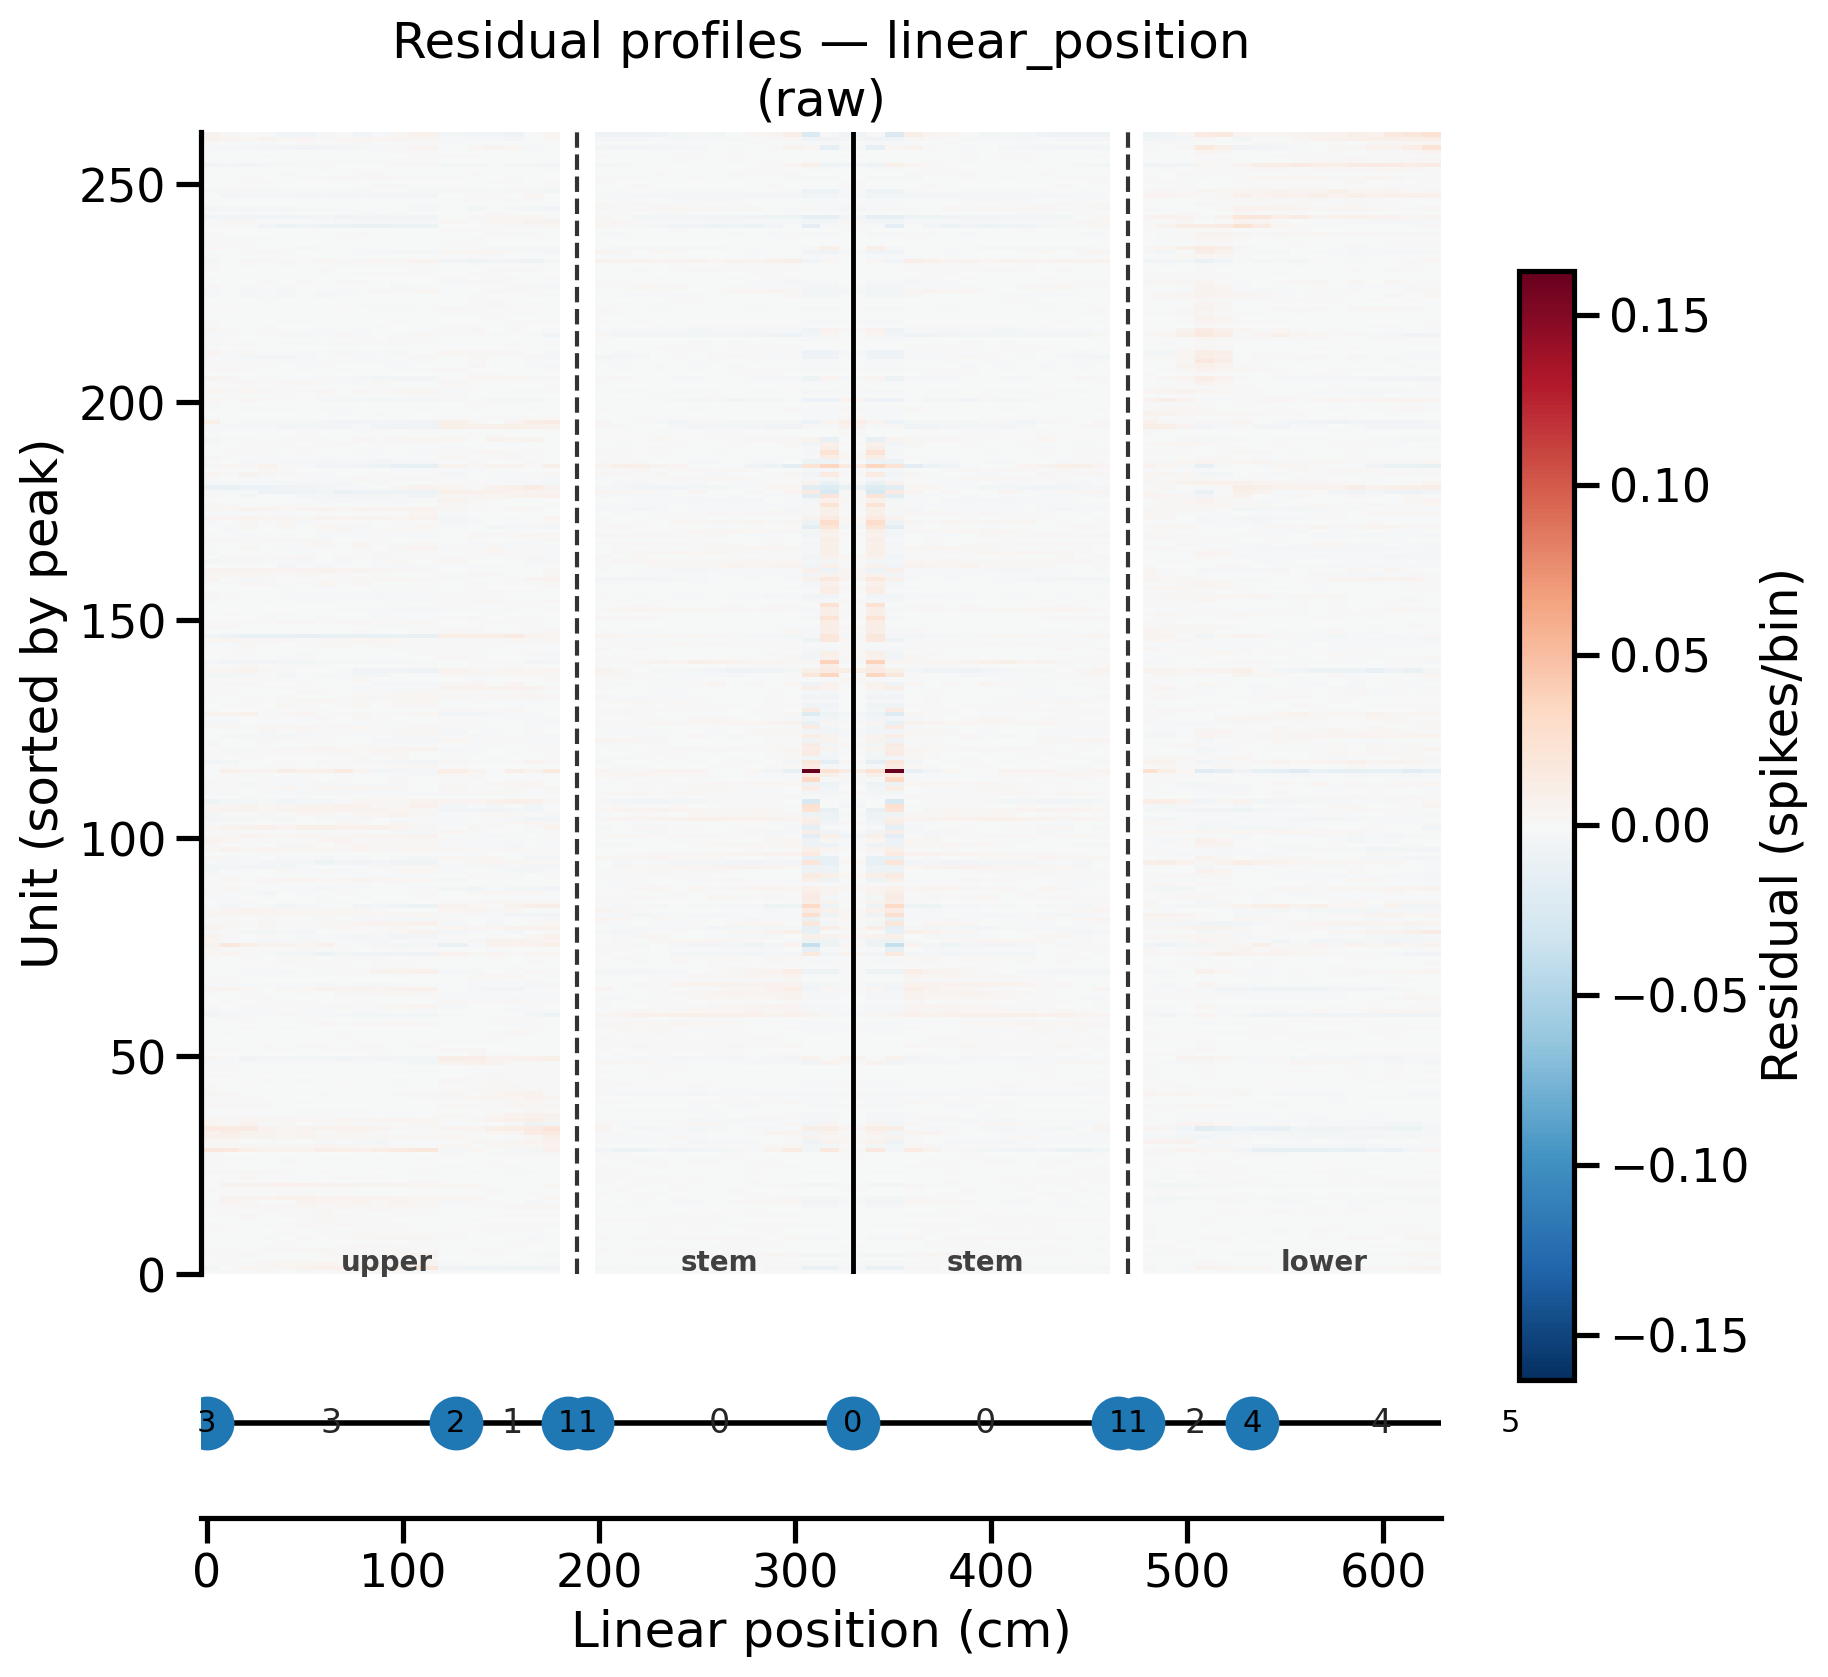

In [37]:
plot_residual_heterogeneity(_prof, variable = "linear_position", row_normalise=False) 

### History model

In [169]:
add_spike_history_mod = partial(add_spike_history, windows_ms=((0, 2), (2, 10), (10, 20), (20, 50))) #modified add_spike_history

In [70]:
history_model_formula = registry["null"]["formula"] + '+ hist_0_2ms + hist_2_10ms + hist_10_20ms + hist_20_50ms'
print(history_model_formula)

spike_count ~ 1+ hist_0_2ms + hist_2_10ms + hist_10_20ms + hist_20_50ms


In [71]:
unit_idx =115
spk_cov_df_common = cov_df_common.copy()
spk_cov_df_common["spike_count"] = spike_counts_common[unit_idx]

results_history = fit_single_unit(history_model_formula,
                                   cov_df_common,
                                   spike_counts_common, 
                                   unit_idx,
                                   per_unit_transform=add_spike_history_mod)
print(results_history.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:            spike_count   No. Observations:               428026
Model:                            GLM   Df Residuals:                   428021
Model Family:                 Poisson   Df Model:                            4
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -9897.9
Date:                Tue, 31 Mar 2026   Deviance:                       16548.
Time:                        16:22:02   Pearson chi2:                 3.98e+05
No. Iterations:                     9   Pseudo R-squ. (CS):           0.003632
Covariance Type:            nonrobust                                         
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept       -5.7870      0.027   -213.335   

In [72]:
#interpret coefficients (exp(intercept + beta_)/bin_size = rate in Hz)
print("Baseline rate = ", np.exp(results_history.params["Intercept"])/0.002)
for name, coef in results_history.params[1:].items():
    print(f"Firing rate at {name} = ", np.exp(results_history.params["Intercept"] + coef)/0.002, f" | coefficient = {coef}")

Baseline rate =  1.5336546771839354
Firing rate at hist_0_2ms =  0.28308346938533413  | coefficient = -1.6896670449483309
Firing rate at hist_2_10ms =  5.945718151655176  | coefficient = 1.3550177571700048
Firing rate at hist_10_20ms =  4.4105295202805825  | coefficient = 1.0563411899303365
Firing rate at hist_20_50ms =  2.1721405992415415  | coefficient = 0.3480595676461752


In [73]:
# Diagnostics : history model
plot_diagnostics(
    results        = results_history,
    spike_counts   = spike_counts_common[unit_idx],
    cov_df         = cov_df_common,
)

In [ ]:
# problem: bursting cell simulations "explode"
windows = ((0,2),(2,10),(10,20),(20,50))
plot_predicted_isi(results_history, windows, title=f"History model: unit {unit_idx}", n_sim=50)


## Combined models

### Full model (trial type, position , speed)

#### Fit on one unit

In [14]:
full_model_formula = registry["full_model"]["formula"] + ' + hist_0_2ms + hist_2_10ms'
print(full_model_formula)

spike_count ~ trial_type + C(branch_id) + bs(branch_pos_scaled, df=4):C(branch_id) + bs(speed_scaled, df=4) + hist_0_2ms + hist_2_10ms


In [15]:
unit_idx = 9
results_full_pos = fit_single_unit(full_model_formula,
                                   cov_df_common, 
                                   spike_counts_common, 
                                   unit_idx,
                                   per_unit_transform=add_spike_history)
print(results_full_pos.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:            spike_count   No. Observations:               433040
Model:                            GLM   Df Residuals:                   433018
Model Family:                 Poisson   Df Model:                           21
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -10043.
Date:                Thu, 16 Apr 2026   Deviance:                       16805.
Time:                        14:56:10   Pearson chi2:                 4.87e+05
No. Iterations:                    22   Pseudo R-squ. (CS):           0.003422
Covariance Type:            nonrobust                                         
                                                          coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------

In [16]:
#plot history coefficients
hist_params = {k: v for k, v in results_full_pos.params.items() if k.startswith("hist_")}
hist_labels = [k.replace("hist_", "").replace("_", "–").replace("ms", " ms") for k in hist_params]

fig, ax = plt.subplots(figsize=(9, 7))
bars = ax.bar(range(len(hist_params)), hist_params.values(), color="steelblue", edgecolor="white")
ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_xticks(range(len(hist_params)))
ax.set_xticklabels(hist_labels)
ax.set_xlabel("Spike history window")
ax.set_ylabel("Coefficient (log scale)")
ax.set_title(f"History term coefficients — unit {unit_idx}")
plt.tight_layout()
plt.show()

In [8]:
# Diagnostics : full model
plot_diagnostics(
    results        = results_full_pos,
    spike_counts   = spike_counts_common[unit_idx],
    cov_df         = cov_df_common,
    show_cumulative=False
)

In [19]:
windows = ((0,2),(2,10)) #many simulations explode
plot_predicted_isi(results_full_pos, windows, title=f"Full model: unit {unit_idx}", n_sim=50)


#### Fit on all units

In [20]:
full_model_formula = registry["full_model"]["formula"] 
full_model_all = fit_glm_all_units(full_model_formula, cov_df_common, spike_counts_common, unit_ids, model_name="full_model", refit = False, fit_history=True)

Loading cached fit from /media/labuser/NA_1_2025/spyglass/wilbur/analysis/full_model_history_model_all.csv


In [21]:
full_model_all.head(1)

,unit,aic,llf,deviance,n_params,n_obs,converged,coef,bse,deviance_null,df_model,error,model
0,0,96681.929970117,-48322.964985058,75419.655857339,18.000000000,428026.000000000,True,"{'Intercept': -2.748615366303212, 'trial_type[...","{'Intercept': 0.0810530490796394, 'trial_type[...",78605.687609937,17.000000000,NaN,full_model_history


In [22]:
diag_full, prof_full = load_model_outputs("full_model_all", fit_history=True)

In [23]:
plot_residual_profiles(prof_full)

/media/labuser/NA_1_2025/spyglass/wilbur/notebooks/encoding_utils.py:2312: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


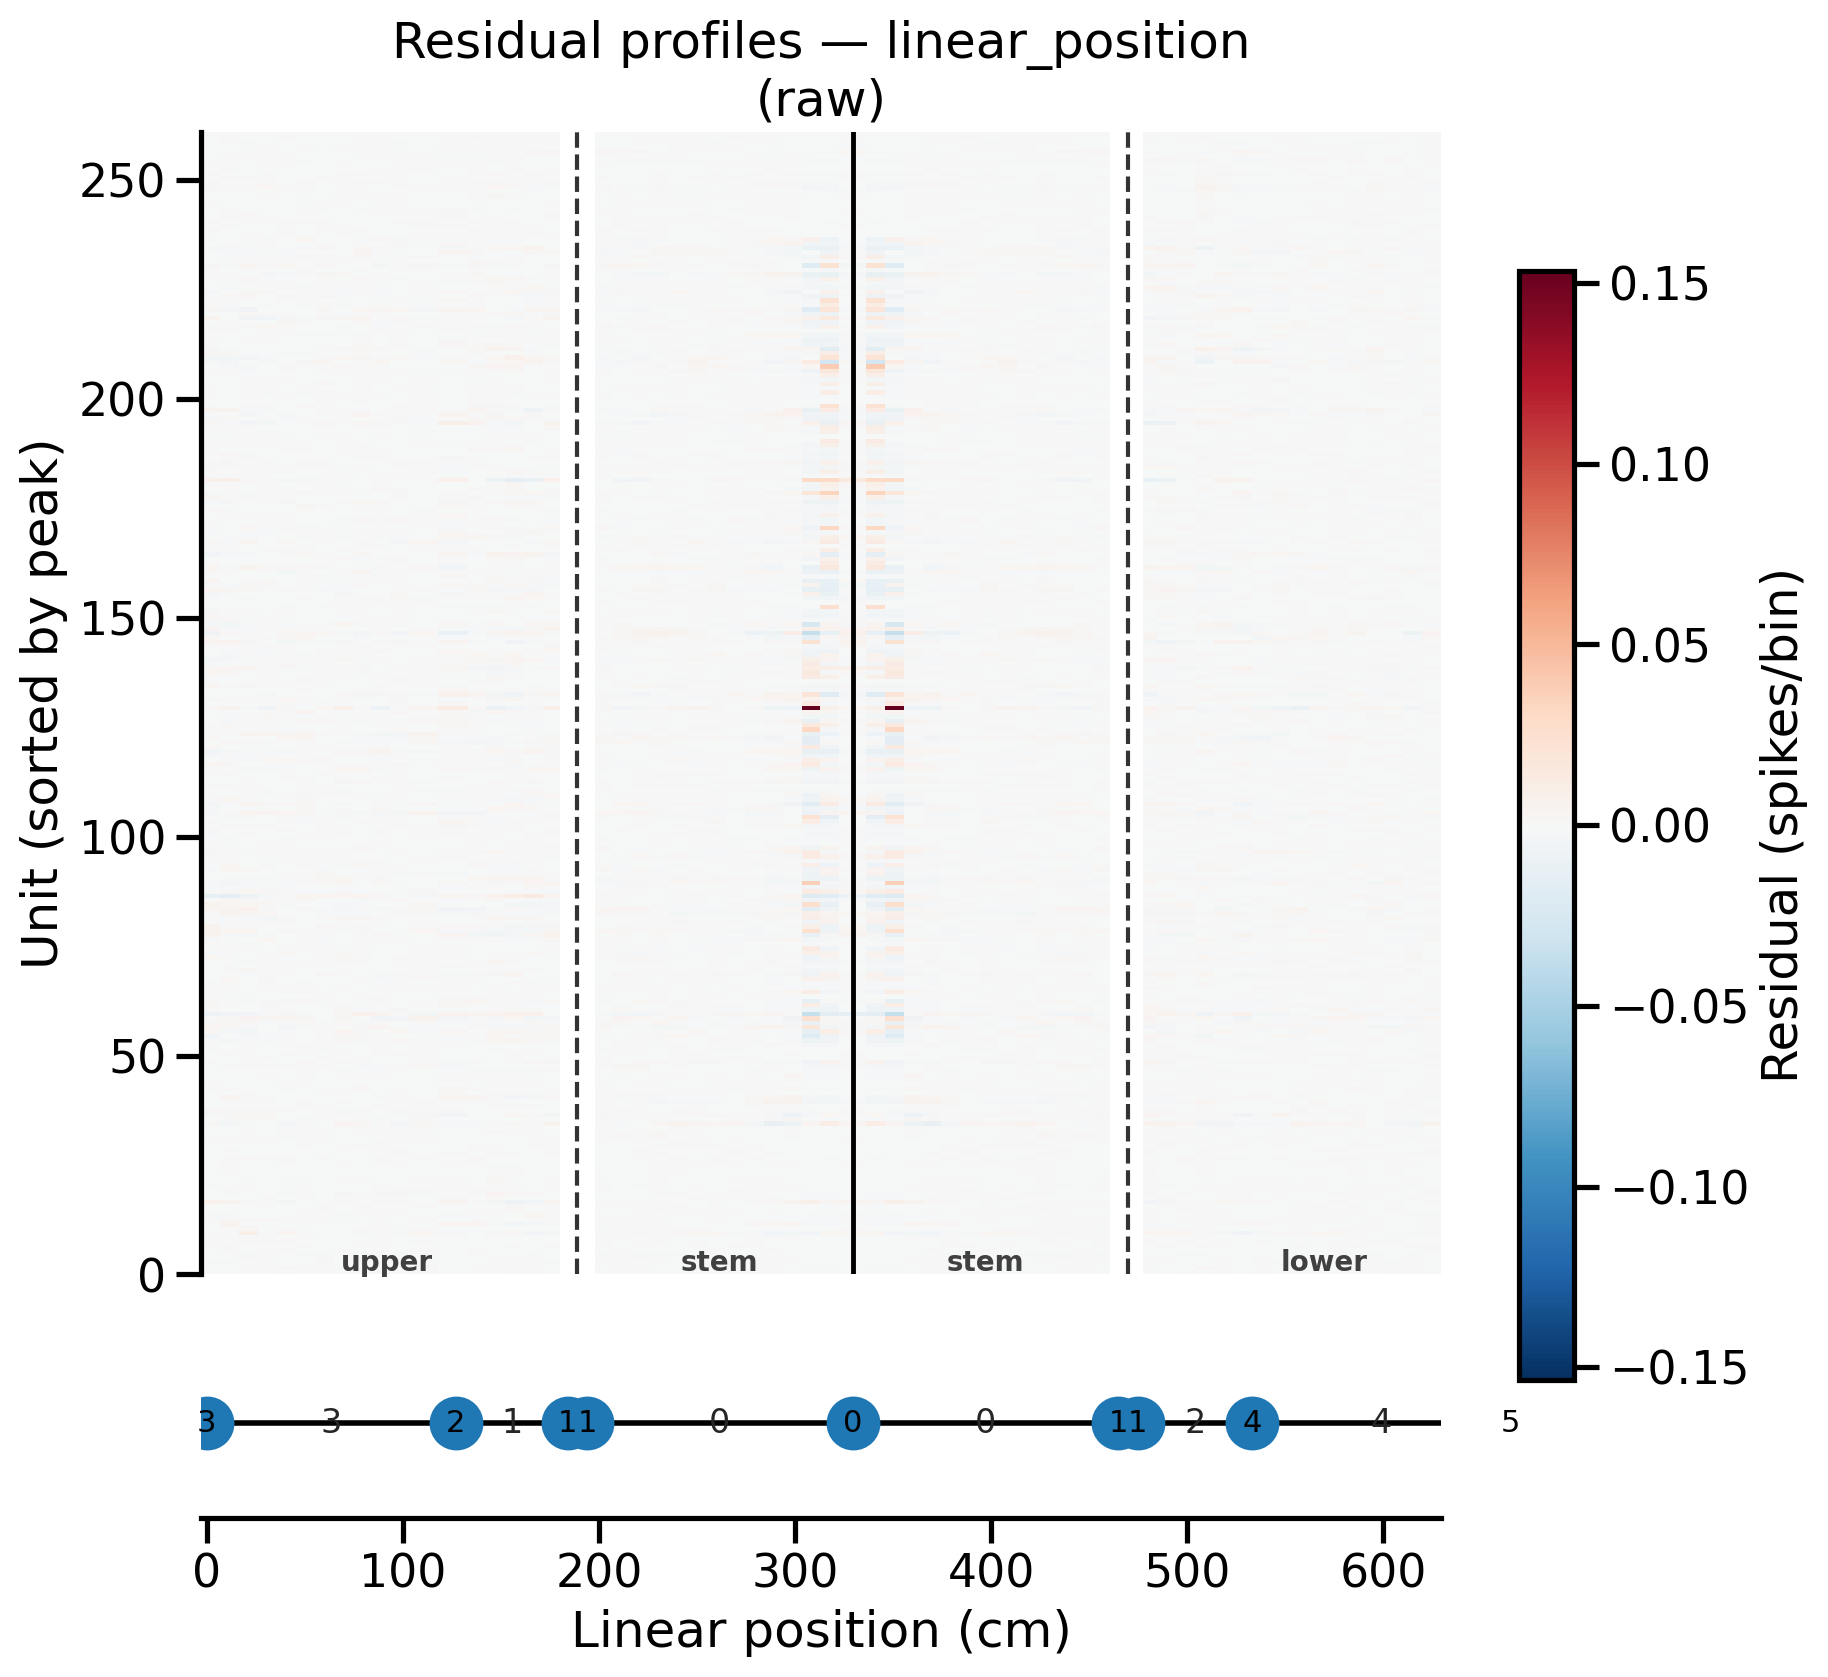

In [32]:
plot_residual_heterogeneity(prof_full, row_normalise=False, variable = "linear_position")

In [27]:
fig, axes, shared = plot_residual_rms_pair_models(
    "null",
    "full_model",
    fit_history_a=False,
    fit_history_b=False,
)


### Temporal full model (trial type, progress, speed)

#### Fit on one unit

In [192]:
temporal_model_formula = registry["temporal_model"]["formula"]
unit_idx = 9
results_temporal = fit_single_unit(temporal_model_formula,
                                   cov_df_common, spike_counts_common, unit_idx)
print(results_temporal.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:            spike_count   No. Observations:               430792
Model:                            GLM   Df Residuals:                   430780
Model Family:                 Poisson   Df Model:                           11
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -10117.
Date:                Tue, 31 Mar 2026   Deviance:                       16929.
Time:                        16:52:28   Pearson chi2:                 4.61e+05
No. Iterations:                     9   Pseudo R-squ. (CS):           0.003367
Covariance Type:            nonrobust                                         
                                                        coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------

In [193]:
# Diagnostics — temporal model
plot_diagnostics(
    results        = results_temporal,
    spike_counts   = spike_counts_common[unit_idx],
    cov_df         = cov_df_common,)

In [194]:
plot_diagnostics_batch(
    unit_list           = UNIT_LIST,
    formula             = temporal_model_formula,
    cov_df              = cov_df_common,
    spike_counts_masked = spike_counts_common,
    unit_ids            = unit_ids,
)

#### Fit on all units

In [ ]:
temporal_model_all = fit_glm_all_units(temporal_model_formula, cov_df_common, spike_counts_common, unit_ids, model_name="temporal_model", refit = False)

In [196]:
diag_temporal, prof_temporal = load_model_outputs("temporal_model_all")

In [197]:
plot_residual_profiles(prof_temporal)

In [ ]:
plot_residual_heterogeneity(prof_temporal, panels = {'trial_progress': 'continuous',
 'speed': 'continuous',
 'trial_type': 'categorical'})

## Model comparison

### Single-variable

In [ ]:
# Load all model CSVs
model_files = {
    "null":                    (f"{base_dir}/analysis/null_model_all.csv",                    dict(keep_default_na=False, na_values=[""])),
    "null_out":                (f"{base_dir}/analysis/null_model_out_all.csv",                dict(keep_default_na=False, na_values=[""])),
    "trial_type":              (f"{base_dir}/analysis/trial_type_model_all.csv",              {}),
    "choice":                  (f"{base_dir}/analysis/choice_model_all.csv",                  {}),
    "speed_spline":            (f"{base_dir}/analysis/speed_spline_model_all.csv",            {}),
    "pos_spline":              (f"{base_dir}/analysis/pos_spline_model_all.csv",              {}),
    "branch_pos_spline":       (f"{base_dir}/analysis/branch_pos_spline_model_all.csv",       {}),
    "trial_progress_spline":   (f"{base_dir}/analysis/trial_progress_spline_model_all.csv",  {}),
    "temporal_model_all":      (f"{base_dir}/analysis/temporal_model_all.csv",               {}),
    "full_model_all":          (f"{base_dir}/analysis/full_model_all.csv",                   {}),
    
}

models = {}
for name, (path, kwargs) in model_files.items():
    df = pd.read_csv(path, index_col=0, **kwargs)
    df["model"] = name
    models[name] = df.set_index("unit")

# Null baseline per model — must match the dataset the model was fit on
null_for = {
    "trial_type":            "null",
    "speed_spline":          "null",
    "pos_spline":            "null",
    "branch_pos_spline":     "null",
    "trial_progress_spline": "null",
    "choice":                "null_out",
    "temporal_model_all":    "null",
    "full_model_all":        "null",
}

rows = []
for model_name, null_name in null_for.items():
    m   = models[model_name]
    nul = models[null_name]

    for uid in m.index:
        row      = m.loc[uid]
        null_row = nul.loc[uid]

        lrt_stat = 2 * (row["llf"] - null_row["llf"])
        lrt_df   = int(row["df_model"]) if pd.notna(row["df_model"]) else 0
        lrt_pval = (1 - chi2.cdf(lrt_stat, lrt_df)) if lrt_df > 0 else np.nan

        rows.append(dict(
            unit        = uid,
            model       = model_name,
            aic         = row["aic"],
            llf         = row["llf"],
            n_params    = row["n_params"],
            n_obs       = row["n_obs"],
            converged   = row["converged"],
            delta_aic   = row["aic"] - null_row["aic"],
            lrt_stat    = lrt_stat,
            lrt_df      = lrt_df,
            lrt_pval    = lrt_pval,
            tuned       = bool(lrt_pval < 0.05) if not np.isnan(lrt_pval) else False,
        ))

comparison = pd.DataFrame(rows)

summary = comparison.groupby("model").agg(
    mean_dAIC  = ("delta_aic", "mean"),
    median_dAIC= ("delta_aic", "median"),
    n_tuned    = ("tuned",     "sum"),
    frac_tuned = ("tuned",     "mean"),
    n_converged= ("converged", "sum"),
).round(3)
print(summary)

In [201]:
# Pivot to wide AIC table : enables direct pairwise model comparison
aic_wide = comparison.pivot(index="unit", columns="model", values="aic")

# Add null baselines 
aic_wide["null"]     = models["null"]["aic"]
aic_wide["null_out"] = models["null_out"]["aic"]

# Best single-variable model per unit (all-trials models only)
all_trials_models = ["trial_type",  "speed_spline", "pos_spline", "branch_pos_spline", "trial_progress_spline", "temporal_model_all", "full_model_all"]
aic_wide["best_model"] = aic_wide[all_trials_models].idxmin(axis=1)
print("Best model counts (all units):")
print(aic_wide["best_model"].value_counts())

Best model counts (all units):
best_model
full_model_all           146
temporal_model_all       108
pos_spline                 5
trial_progress_spline      2
speed_spline               1
Name: count, dtype: int64


/tmp/ipykernel_2973269/1296881454.py:10: FutureWarning: The behavior of DataFrame.idxmin with all-NA values, or any-NA and skipna=False, is deprecated. In a future version this will raise ValueError
  aic_wide["best_model"] = aic_wide[all_trials_models].idxmin(axis=1)


In [203]:
#full model improvement over null
glm_full = pd.read_csv(f"{base_dir}/analysis/full_model_all.csv", index_col=0)
glm_full = glm_full[glm_full["converged"] == True].copy()

df_model  = glm_full["n_params"] - 1                              # degrees of freedom vs null
lrt_stat  = glm_full["deviance_null"] - glm_full["deviance"]      # 2*(llf_full - llf_null)
lrt_pval  = 1 - chi2.cdf(lrt_stat, df_model)                      # per-unit p-value

n_sig  = (lrt_pval < 0.05).sum()
_, pop_pval = wilcoxon(lrt_stat, zero_method="wilcox", alternative="greater")  # population: LRT > 0?

fig, axes = plt.subplots(1, 2, figsize=(10, 4), constrained_layout=True)

# Panel A: LRT statistic distribution
ax = axes[0]
ax.hist(lrt_stat, bins=40, color="steelblue", edgecolor="none", alpha=0.8)
ax.axvline(lrt_stat.median(), color="orange", lw=1.5,
           label=f"median = {lrt_stat.median():.1f}")
ax.set_xlabel("LRT statistic")
ax.set_ylabel("Number of units")
ax.set_title(f"LRT: full vs null  (n={len(lrt_stat)} units)\nWilcoxon p = {pop_pval:.2e}")
ax.legend(fontsize=9)
sns.despine(ax=ax)

# Panel B: per-unit p-value histogram
ax = axes[1]
ax.hist(lrt_pval, bins=40, color="steelblue", edgecolor="none", alpha=0.8)
ax.axvline(0.05, color="red", lw=1.5, ls="--", label="p = 0.05")
ax.set_xlabel("Per-unit LRT p-value")
ax.set_ylabel("Number of units")
ax.set_title(f"{n_sig}/{len(lrt_pval)} units significant (p < 0.05)")
ax.legend(fontsize=9)
sns.despine(ax=ax)


### Drop-one & LRT (combined models)

In [12]:
# without history terms
datasets = {
    "common":   (cov_df_common, spike_counts_common),
}

drop_one_specs = make_drop_one_specs(
    datasets=datasets,
    model_names=["full_model"],
)

In [11]:
drop_one_specs

{'full_model_all': {'formula_lhs': 'spike_count',
  'terms': ['trial_type',
   'C(branch_id)',
   'bs(branch_pos_scaled, df=4):C(branch_id)',
   'bs(speed_scaled, df=4)'],
  'delta_df': {'trial_type': 1,
   'C(branch_id)': 1,
   'bs(branch_pos_scaled, df=4):C(branch_id)': 4,
   'bs(speed_scaled, df=4)': 4},
  'cov_df':              time_bin_center    position_x   position_y  orientation  \
  58006   1620843591.630850554 132.750034472  5.170402462  0.003915443   
  58007   1620843591.632850647 132.794526275  5.160177630  0.003188238   
  58008   1620843591.634850740 132.839018077  5.149952798  0.002461034   
  58009   1620843591.636850834 132.883509880  5.139727965  0.001733830   
  58010   1620843591.638850927 132.928001683  5.129503133  0.001006625   
  ...                      ...           ...          ...          ...   
  3892182 1620851260.341192961 109.950035395 65.418707126  0.006183992   
  3892183 1620851260.343193054 110.106673359 65.432120755  0.010656286   
  3892184 16208

In [ ]:
#check_if_exists=True skips already-saved CSVs
for model_name in drop_one_specs:
    run_drop_one_suite(drop_one_specs, model_name, base_dir, unit_ids, check_if_exists=True, )

In [ ]:
# Compute LRT for all models and concatenate 
lrt_frames = [compute_drop_one_lrt(model_name, base_dir, drop_one_specs) for model_name in drop_one_specs]
drop_one_results = pd.concat(lrt_frames, ignore_index=True)

print(drop_one_results.shape)


In [218]:
# Summary table 
summary_drop = (
    drop_one_results
    .groupby(["model", "dropped_term"])
    .agg(
        n_units          = ("unit",        "count"),
        n_significant    = ("significant", "sum"),
        frac_significant = ("significant", "mean"),
        mean_delta_aic   = ("delta_aic",   "mean"),
        median_delta_aic = ("delta_aic",   "median"),
    )
    .round(3)
)
print(summary_drop.to_string())

# Short labels for plotting 
term_labels = {
    "trial_type": "trial_type",
    "choice":     "choice",
    "bs(pos_scaled, df = 8)":                             "position",
    "bs(speed_scaled, df = 4)":                           "speed",
    "cr(trial_progress, df = 6, constraints = 'center')": "trial_progress",
}
plot_df = drop_one_results.copy()
plot_df["term_label"] = plot_df["dropped_term"].map(term_labels).fillna(plot_df["dropped_term"])

summary_plot = (
    plot_df.groupby(["model", "term_label"])
    .agg(frac_significant=("significant", "mean"), mean_delta_aic=("delta_aic", "mean"))
    .round(3)
)

# Figure: fraction significant + mean delta AIC
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
summary_plot["frac_significant"].unstack("term_label").plot.barh(ax=ax)
ax.axvline(0.05, color="red", lw=1, ls="--", label="α=0.05")
ax.set_xlabel("fraction of units (LRT p < 0.05)")
ax.set_title("Unique contribution: fraction significant")
ax.legend(title="dropped term", fontsize=8, loc="lower right")
sns.despine(ax=ax)

ax = axes[1]
summary_plot["mean_delta_aic"].unstack("term_label").plot.barh(ax=ax)
ax.axvline(0, color="black", lw=0.8, ls="--")
ax.set_xlabel("mean ΔAIC (full − reduced)\nnegative = full model better")
ax.set_title("Unique contribution: effect size (AIC)")
ax.legend(title="dropped term", fontsize=8, loc="lower right")
sns.despine(ax=ax)

plt.tight_layout()

# Figure: per-unit delta AIC distributions 
g = sns.FacetGrid(plot_df, col="model", col_wrap=2, height=4, sharey=False, sharex=False)
g.map_dataframe(
    sns.boxplot, x="delta_aic", y="term_label",
    color="steelblue", width=0.5, flierprops=dict(marker=".", ms=3)
)
g.map(plt.axvline, x=0, color="red", lw=1, ls="--")
g.set_axis_labels("ΔAIC (full − reduced)", "dropped term")
g.set_titles("{col_name}")
sns.despine()
plt.tight_layout()

                                       n_units  n_significant  frac_significant  mean_delta_aic  median_delta_aic
model          dropped_term                                                                                      
full_model_all bs(pos_scaled, df=8)        258            252       0.977000000  -254.448000000    -147.207000000
               bs(speed_scaled, df=4)      258            243       0.942000000  -248.914000000    -105.285000000
               trial_type                  257            187       0.728000000   -49.237000000     -13.582000000


### Statistical summary

In [219]:
# FDR correction : 
drop_one_results = apply_fdr_correction(drop_one_results)


In [221]:
# Pairwise comparison : run for each combined model
pw_full     = pairwise_term_comparison(drop_one_results, 'full_model_all')

print('Full model pairwise q-values:')
print(pw_full.round(3).to_string())


Full model pairwise q-values:
                        bs(pos_scaled, df=8)  bs(speed_scaled, df=4)  trial_type
bs(pos_scaled, df=8)                     NaN             0.003000000 0.000000000
bs(speed_scaled, df=4)           0.003000000                     NaN 0.000000000
trial_type                       0.000000000             0.000000000         NaN


In [222]:
plot_drop_one_summary(drop_one_results, pairwise_pvals=pw_full,
                      heatmap_model='full_model_all')
